# Israeli Actors Graph — Temporal Period Analysis (Step 2)

Full metric suite for each of the three periods (A: ≤1970, B: 1970-1990,
C: >1990): basic graph metrics, connectivity metrics, and degree
distribution, followed by a comparison across periods.

Radius and diameter are undefined on a disconnected graph, so they're
computed on each period's **largest connected component** only (via the
course's `utils.get_giant_component` helper); density/clustering/degree
stats use the full period graph (isolated actors included).

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
sys.path.insert(0, os.path.abspath("../.."))  # repo root, for utils.py
import graph_build
import graph_metrics
import utils

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout.reconfigure(encoding="utf-8")

plt.rcParams["font.family"] = "Arial"  # better Hebrew glyph coverage than the default

## Rebuild the graph and split into periods

In [3]:
cast_edges = graph_build.load_cast_edges("../data/processed/cast_edges.csv")
G = graph_build.build_full_graph(cast_edges)
periods = {p: graph_build.period_subgraph(G, p) for p in ["A", "B", "C"]}

for p, H in periods.items():
    print(f"Period {p}:")
    utils.print_graph_info(H)
    print()

Period A:
Graph is undirected and weighted.
Graph is disconnected.
Number of nodes:	    132
Number of edges:	    472
Density:		0.055

Period B:
Graph is undirected and weighted.
Graph is disconnected.
Number of nodes:	    335
Number of edges:	    930
Density:		0.017

Period C:
Graph is undirected and weighted.
Graph is disconnected.
Number of nodes:	  1,106
Number of edges:	  4,731
Density:		0.008



## Full metric table

In [4]:
metrics = graph_metrics.metrics_table(periods)
metrics.round(3)

,n_actors,n_collaborations,density,avg_clustering,avg_degree,max_degree,n_components,largest_component_size,largest_component_frac,radius,diameter
A,132.0,472.0,0.055,0.742,7.152,34.0,3.0,128.0,0.970,4.0,6.0
B,335.0,930.0,0.017,0.659,5.552,48.0,24.0,289.0,0.863,3.0,6.0
C,1106.0,4731.0,0.008,0.751,8.555,62.0,49.0,989.0,0.894,5.0,9.0


### What each column means

| Column | Meaning |
|---|---|
| `n_actors` / `n_collaborations` | nodes / edges in the period graph |
| `density` | fraction of all possible actor pairs that actually collaborated |
| `avg_clustering` | how often two of an actor's co-stars also worked with each other |
| `avg_degree` / `max_degree` | mean / highest number of distinct co-stars |
| `n_components` | number of disconnected pieces |
| `largest_component_size` / `_frac` | size of the biggest connected piece, and its share of all actors |
| `radius` / `diameter` | shortest-path radius/diameter **within the largest component only** |

## Degree distribution per period

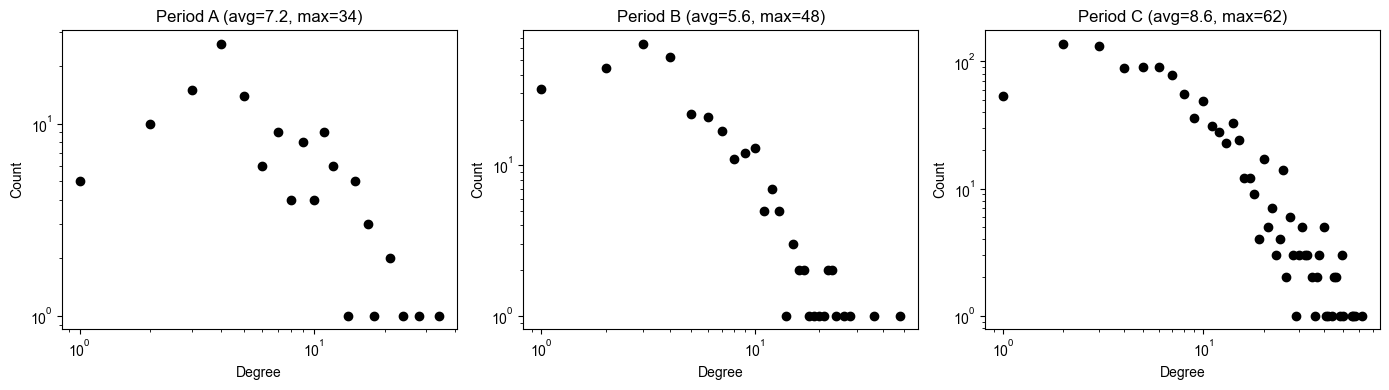

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
degree_stats = {}
for ax, p in zip(axes, ["A", "B", "C"]):
    degrees = np.array([d for _, d in periods[p].degree()])
    degree_stats[p] = degrees
    utils.log_log_plot(degrees, str_title=f"Period {p} (avg={degrees.mean():.1f}, max={degrees.max()})", ax=ax)
plt.tight_layout()
plt.show()

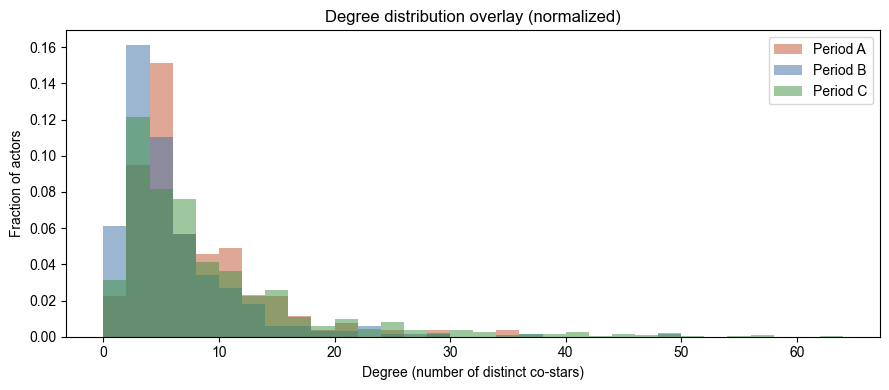

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for p, color in zip(["A", "B", "C"], ["#c0522f", "#3b6ea5", "#3f9142"]):
    ax.hist(degree_stats[p], bins=range(0, 65, 2), alpha=0.5, label=f"Period {p}", color=color, density=True)
ax.set_xlabel("Degree (number of distinct co-stars)")
ax.set_ylabel("Fraction of actors")
ax.set_title("Degree distribution overlay (normalized)")
ax.legend()
plt.tight_layout()
plt.show()

## Comparing periods across all metrics

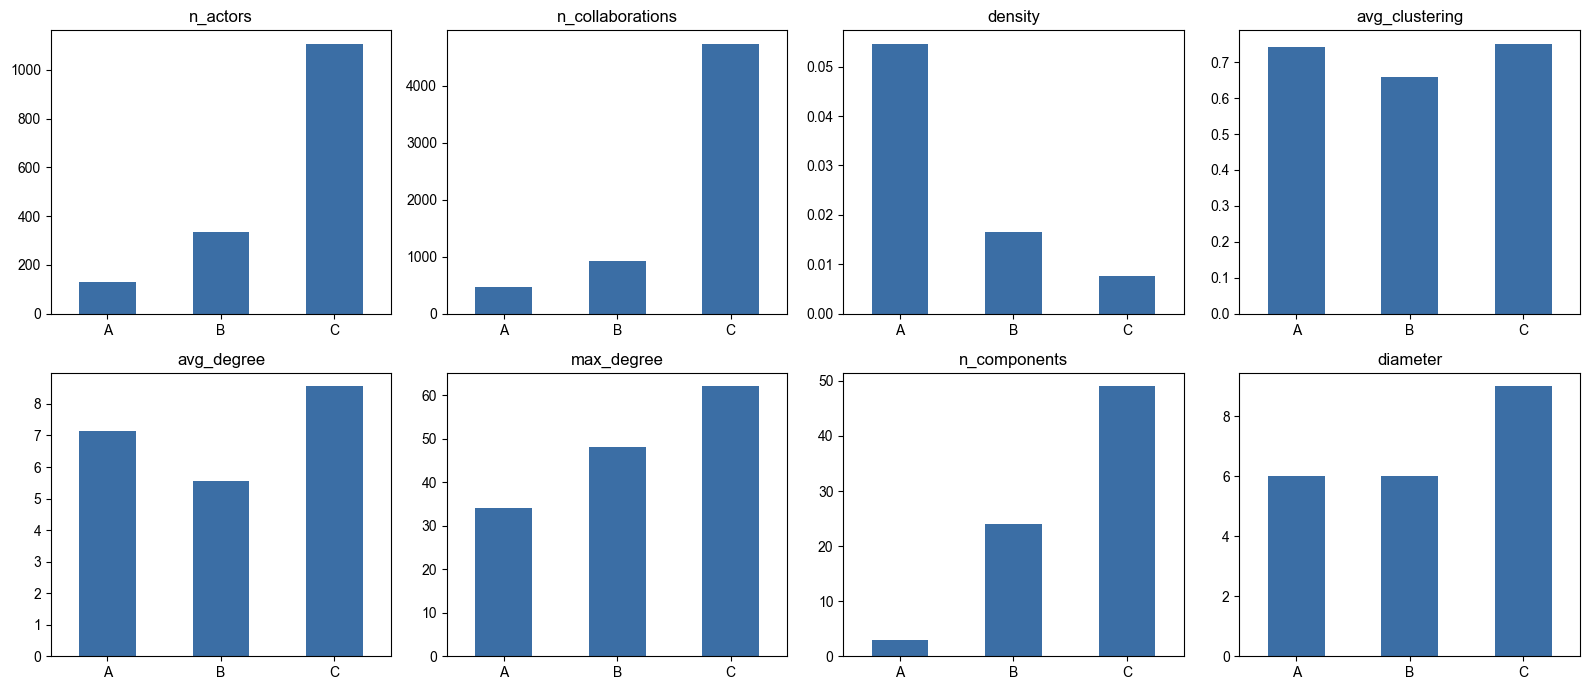

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
plot_cols = ["n_actors", "n_collaborations", "density", "avg_clustering",
             "avg_degree", "max_degree", "n_components", "diameter"]
for ax, col in zip(axes.flat, plot_cols):
    metrics[col].plot(kind="bar", ax=ax, color="#3b6ea5")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Connected components: how fragmented is each period?

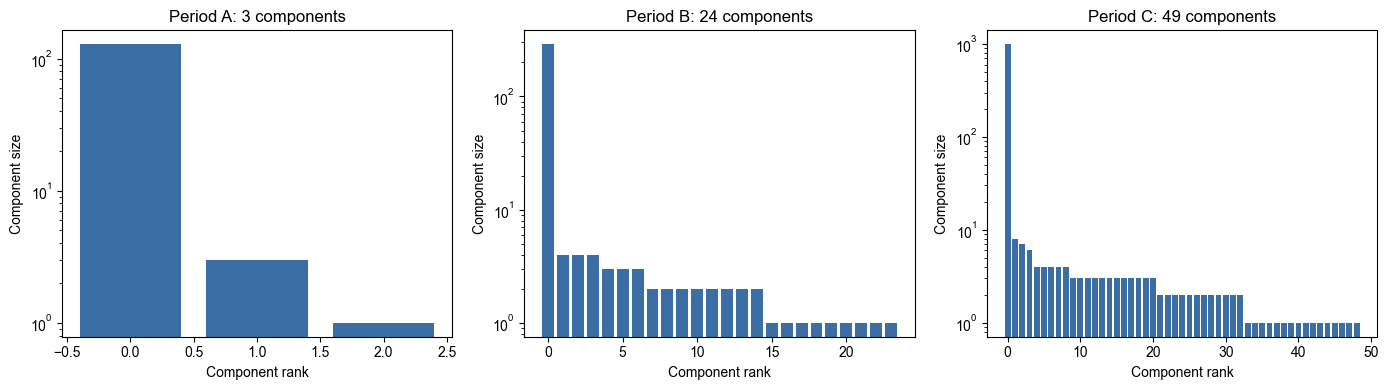

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, p in zip(axes, ["A", "B", "C"]):
    comp_sizes = sorted((len(c) for c in nx.connected_components(periods[p])), reverse=True)
    ax.bar(range(len(comp_sizes)), comp_sizes, color="#3b6ea5")
    ax.set_title(f"Period {p}: {len(comp_sizes)} components")
    ax.set_xlabel("Component rank")
    ax.set_ylabel("Component size")
    ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Observed trends

In [9]:
for p in ["A", "B", "C"]:
    m = metrics.loc[p]
    print(f"Period {p}: {int(m.n_actors)} actors, {int(m.n_collaborations)} collaborations, "
          f"density={m.density:.4f}, avg_clustering={m.avg_clustering:.3f}, "
          f"avg_degree={m.avg_degree:.2f}, largest component={int(m.largest_component_size)} "
          f"({m.largest_component_frac:.1%} of actors), diameter={m.diameter:.0f}")

Period A: 132 actors, 472 collaborations, density=0.0546, avg_clustering=0.742, avg_degree=7.15, largest component=128 (97.0% of actors), diameter=6
Period B: 335 actors, 930 collaborations, density=0.0166, avg_clustering=0.659, avg_degree=5.55, largest component=289 (86.3% of actors), diameter=6
Period C: 1106 actors, 4731 collaborations, density=0.0077, avg_clustering=0.751, avg_degree=8.56, largest component=989 (89.4% of actors), diameter=9


Based on the numbers above:

- **Growth**: the network grows sharply in size across periods — from a
  small pre-1970 cast pool to a much larger, more prolific industry after
  1990, tracking the overall growth in film output seen in Notebook 1.
- **Density falls as the network grows** — expected for any real
  collaboration network: with far more actors, the *fraction* of all
  possible pairs who've worked together necessarily shrinks, even as the
  *absolute* number of collaborations grows a lot.
- **Clustering stays consistently high (~0.65-0.75) across all three
  periods** — actors' co-stars tend to also know each other, a signature of
  a tight-knit industry where the same ensembles/repertory groups recur,
  and this doesn't erode even as the industry scales up.
- **Fragmentation**: the number of disconnected components grows with the
  network (few components in A, many more by C), yet the *largest*
  component still captures the large majority of actors in every period —
  a classic giant-component pattern, with a long tail of small isolated
  troupes/one-off productions alongside one dominant, well-connected core.
- **Diameter grows only modestly** despite the large increase in actor
  count — consistent with small-world behavior: the well-connected core
  keeps typical actor-to-actor distances short even as the industry scales
  up by nearly an order of magnitude from Period A to Period C.

## Save the metrics table

In [10]:
try:
    metrics.to_csv("../data/processed/period_metrics.csv")
    print("Saved period_metrics.csv to data/processed/")
except PermissionError:
    print("Could not write period_metrics.csv (likely locked by another program) -- skipping save.")

Saved period_metrics.csv to data/processed/


## Next steps

`04_community_detection.ipynb`: community detection on Period C (Louvain vs.
greedy modularity vs. label propagation).